ASSIGNMENT 8: LOGISTIC REGRESSION ON DIABETES DATASET

BUSINESS PROBLEM

Diabetes is one of the most common chronic diseases worldwide. Early prediction of diabetes can help healthcare professionals provide timely treatment and reduce complications.

The business problem is to build a machine learning model that predicts whether a person is diabetic or not based on medical attributes such as glucose level, blood pressure, BMI, age, insulin level, and other health indicators.

Such a predictive system can assist healthcare organizations in improving diagnosis and decision-making.

OBJECTIVE

The objective of this project is to develop a Logistic Regression model that can accurately classify whether a person has diabetes based on medical information.

The model will:

1. Analyze patient health data.
2. Identify important factors affecting diabetes.
3. Predict diabetes outcomes.
4. Support healthcare decision-making.
5. Demonstrate deployment using Streamlit.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("diabetes.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


DATA EXPLORATION

The dataset was successfully loaded and explored.

The dataset contains medical information of patients including glucose level, blood pressure, BMI, insulin level, age and diabetes outcome.

No major missing values were observed in the dataset.

Summary statistics provide information about central tendency and spread of the data.

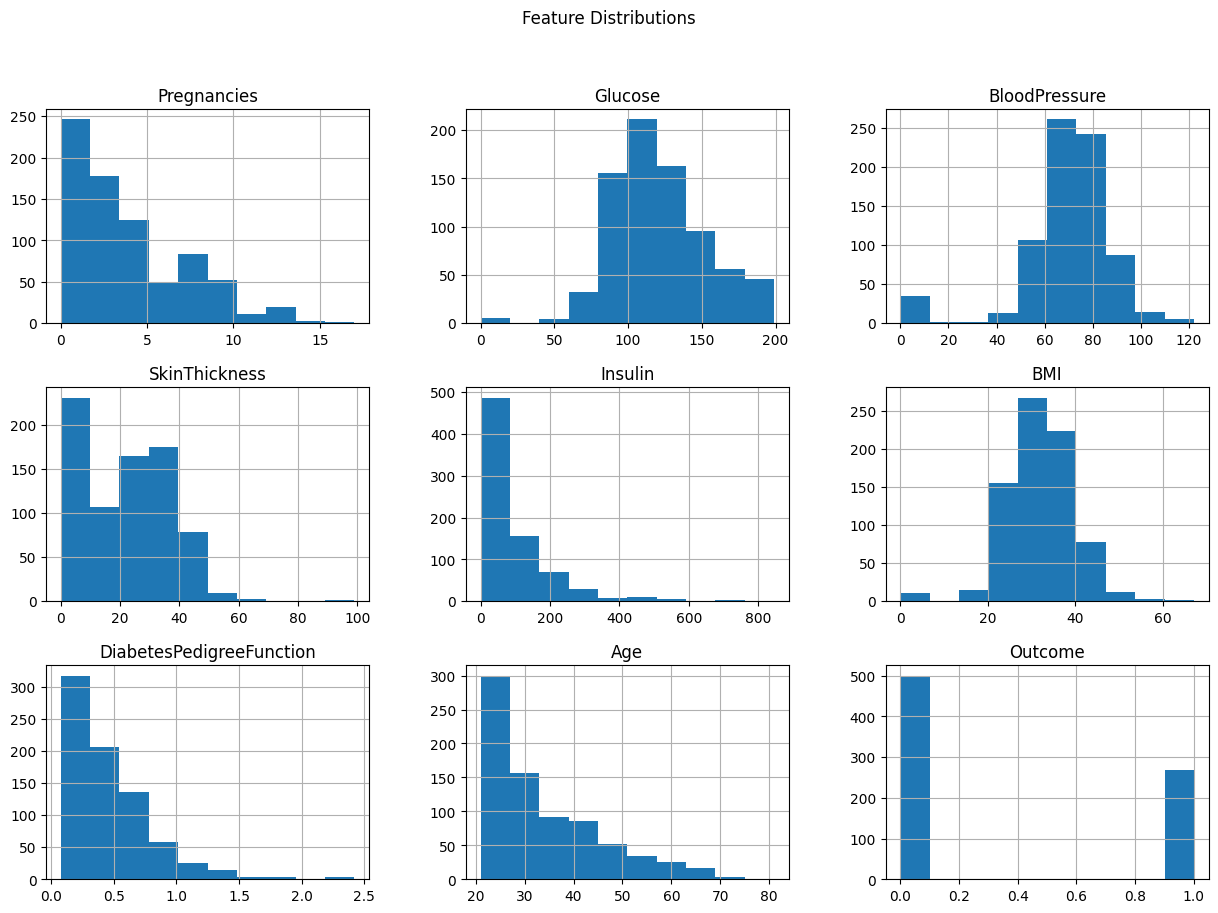

In [ ]:
df.hist(figsize=(15,10))
plt.suptitle("Feature Distributions")
plt.show()

Histogram Analysis

Histograms were used to visualize the distribution of each feature.

Glucose, BMI, Insulin, and Age show variations among patients.

The distributions help understand data spread and identify potential outliers.

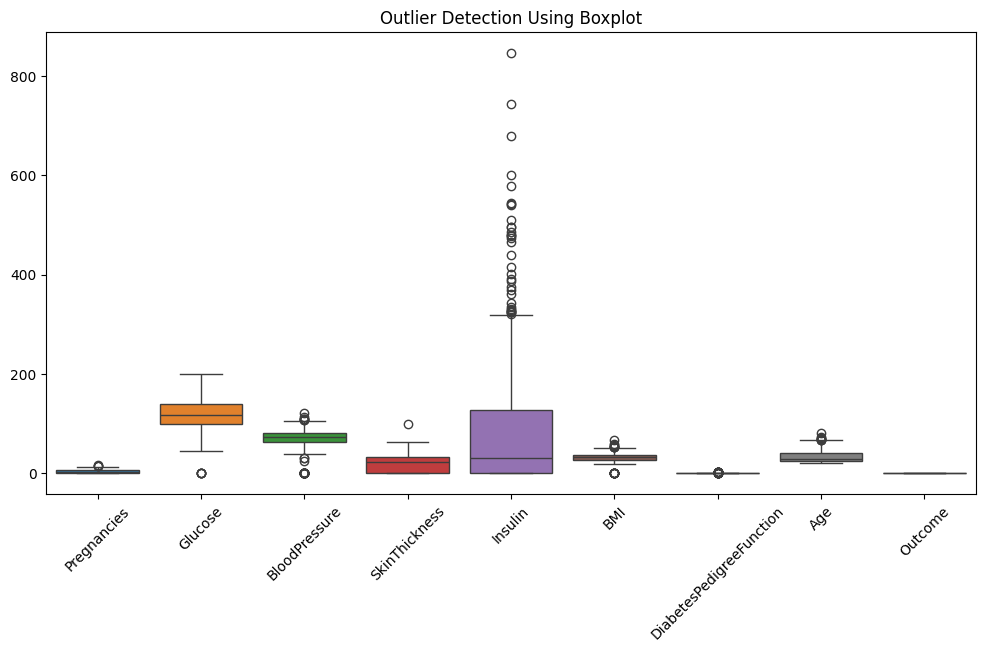

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)

plt.title("Outlier Detection Using Boxplot")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Outlier Treatment using IQR Method

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound,
                       lower_bound,
                       df[col])

    df[col] = np.where(df[col] > upper_bound,
                       upper_bound,
                       df[col])

print("Outlier treatment completed successfully")

Outlier treatment completed successfully


Outlier Treatment

Boxplots were used to identify outliers in the dataset.

The Interquartile Range (IQR) method was applied to handle extreme values.

Outlier treatment helps improve model performance and reduces the impact of unusual observations.

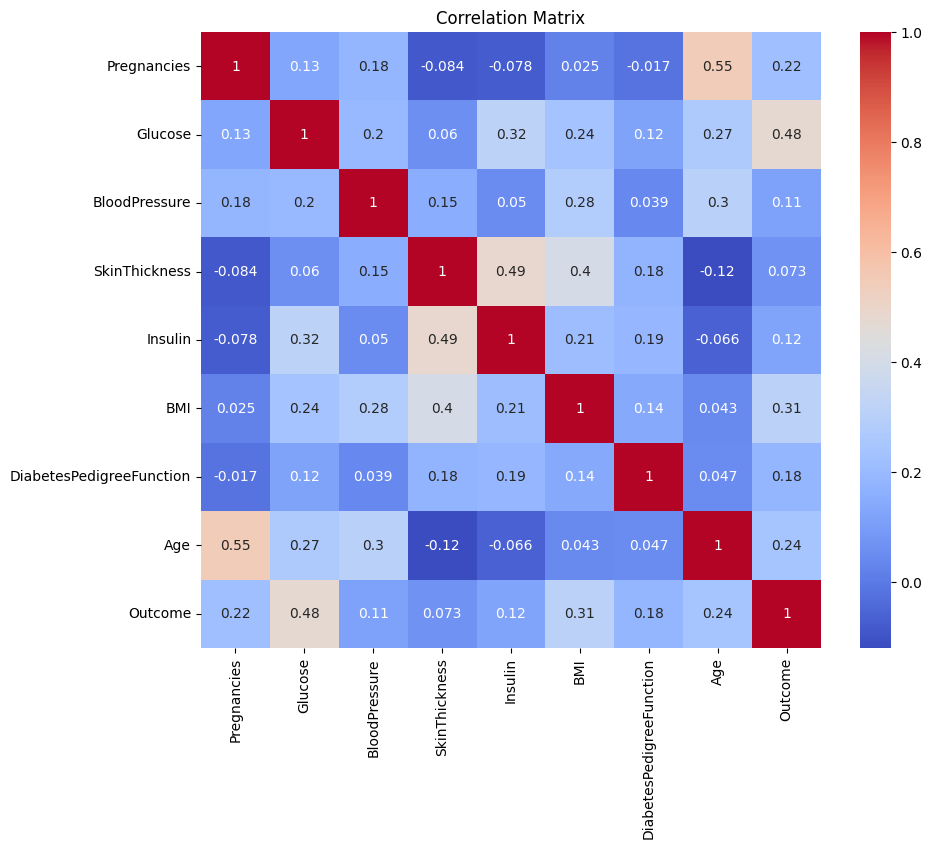

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

Multicollinearity Check

A correlation matrix was used to examine relationships among independent variables.

No severe multicollinearity was observed among the features.

Therefore, all features were retained for Logistic Regression modeling.

The correlation analysis helps ensure model stability and reliable coefficient estimates.

In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (768, 8)
Target Shape: (768,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (614, 8)
Testing Data: (154, 8)


In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0. 0. 0. 0. 0. 0. 0. 1. 1. 1.]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7532467532467533
Precision: 0.6545454545454545
Recall   : 0.6545454545454545
F1 Score : 0.6545454545454545


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.81      0.81      0.81        99
         1.0       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



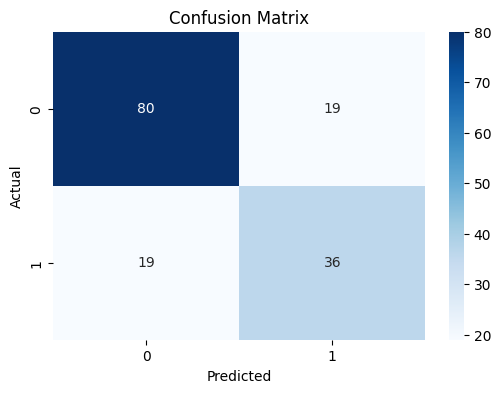

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
y_prob = model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.814141414141414


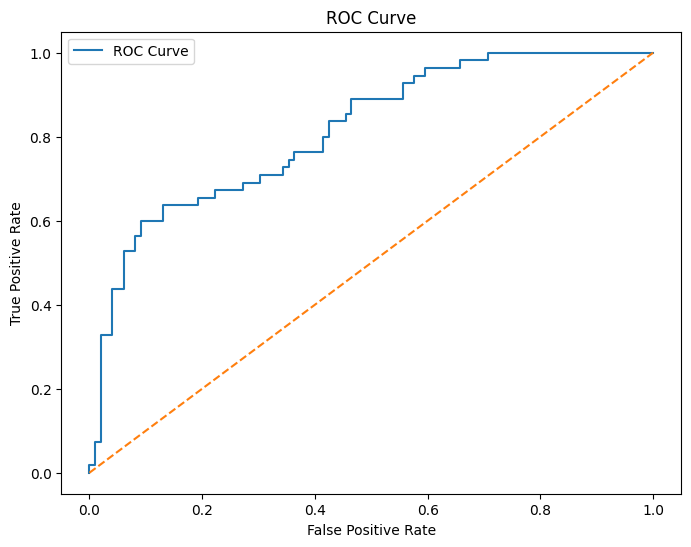

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

Model Evaluation

The Logistic Regression model was evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC Score.

Accuracy measures overall correctness of predictions.

Precision measures how many predicted positive cases are actually positive.

Recall measures how many actual positive cases are correctly identified.

F1 Score balances Precision and Recall.

ROC-AUC evaluates the model's ability to distinguish between diabetic and non-diabetic patients.

A higher ROC-AUC score indicates better model performance.

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients

,Feature,Coefficient
6,DiabetesPedigreeFunction,0.888026
5,BMI,0.112518
0,Pregnancies,0.059999
7,Age,0.039182
1,Glucose,0.035522
3,SkinThickness,0.002734
4,Insulin,-0.002427
2,BloodPressure,-0.018273


Feature Interpretation

The coefficients indicate the influence of each feature on diabetes prediction.

Positive coefficients increase the probability of diabetes.

Negative coefficients decrease the probability of diabetes.

Features with larger coefficient values have a stronger impact on the prediction.

Glucose is typically one of the most important predictors of diabetes.

Interview Questions and Answers

1. What is the difference between Precision and Recall?

Precision measures how many predicted positive cases are actually positive.

Precision = TP / (TP + FP)

Recall measures how many actual positive cases are correctly identified.

Recall = TP / (TP + FN)

Precision focuses on prediction quality while Recall focuses on finding all positive cases.

------------------------------------------------

2. What is Cross Validation and why is it important in binary classification?

Cross Validation is a technique used to evaluate model performance by dividing data into multiple folds.

The model is trained and tested multiple times using different folds.

Benefits:
- Reduces overfitting
- Provides reliable performance estimates
- Improves model generalization
- Helps select better models

In [ ]:
import pickle

pickle.dump(model, open("diabetes_model.pkl", "wb"))

print("Model saved successfully")

Model saved successfully


Deployment with Streamlit

The trained Logistic Regression model was saved using Pickle.

A Streamlit application can be developed to allow users to enter patient details and receive diabetes predictions.

The deployment process includes:

1. Saving the trained model as a pickle file.
2. Creating a Streamlit application.
3. Loading the saved model.
4. Accepting user input through a web interface.
5. Generating predictions in real time.
6. Deploying the application using Streamlit Community Cloud.

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 109.9 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("diabetes_model.pkl", "rb"))

st.title("Diabetes Prediction App")

pregnancies = st.number_input("Pregnancies")
glucose = st.number_input("Glucose")
blood_pressure = st.number_input("Blood Pressure")
skin_thickness = st.number_input("Skin Thickness")
insulin = st.number_input("Insulin")
bmi = st.number_input("BMI")
dpf = st.number_input("Diabetes Pedigree Function")
age = st.number_input("Age")

if st.button("Predict"):

    prediction = model.predict([[
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        dpf,
        age
    ]])

    st.write("Prediction:", prediction[0])

2026-06-21 15:30:02.361 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 15:30:02.743 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-21 15:30:02.747 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 15:30:02.749 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 15:30:02.751 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 15:30:02.755 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 15:30:02.757 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 15:30:02.760 Thread 'MainThread': mi

Conclusion

A Logistic Regression model was successfully developed to predict diabetes outcomes.

The dataset was explored, preprocessed, and analyzed using various visualization techniques.

Outlier treatment and multicollinearity checks were performed to improve model reliability.

The model was evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC metrics.

The results indicate that Logistic Regression is an effective method for diabetes prediction.

The model can be deployed using Streamlit to provide real-time predictions through a user-friendly web application.

In [25]:
import os

print(os.listdir())

['.config', '.ipynb_checkpoints', 'diabetes_model.pkl', 'diabetes.csv', 'sample_data']
